# TASKS

Accuracy: 1.0


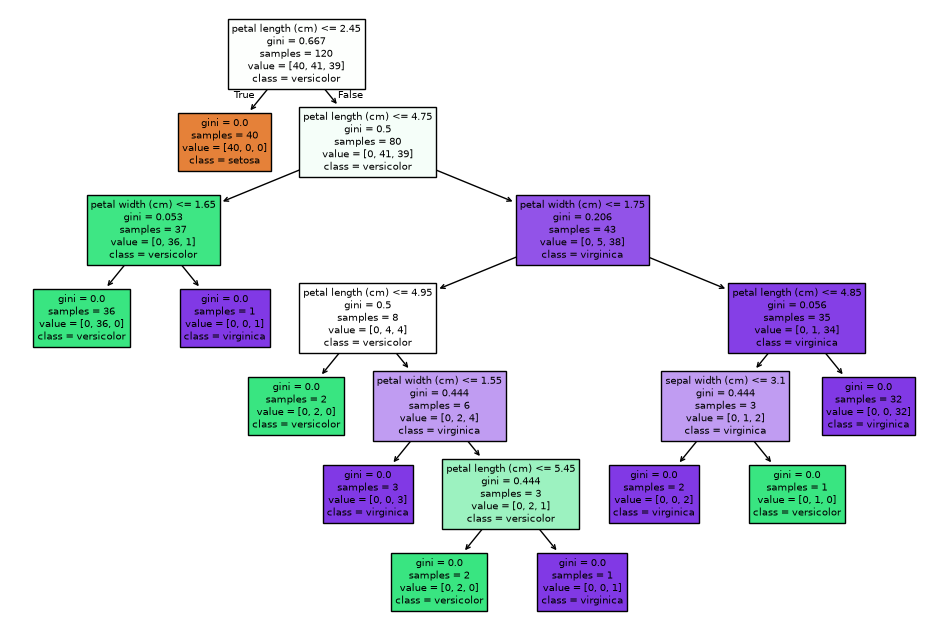

In [7]:
#1. Decision Tree on Iris + Tree Visualization
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Visualize Tree
plt.figure(figsize=(12,8))
plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.show()

In [8]:
#2. Tune max_depth and Compare Accuracy
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("Depth\tAccuracy")

for depth in range(1, 11):
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"{depth}\t{acc:.4f}")

Depth	Accuracy
1	0.6333
2	0.9667
3	1.0000
4	1.0000
5	1.0000
6	1.0000
7	1.0000
8	1.0000
9	1.0000
10	1.0000


In [9]:
#3. Random Forest on Titanic Dataset
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Select features
features = ["Pclass", "Sex", "Age", "Fare"]

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Sex"] = df["Sex"].map({"male":0, "female":1})

X = df[features]
y = df["Survived"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred))

Random Forest Accuracy: 0.7932960893854749


  Feature  Importance
3    Fare    0.333191
1     Sex    0.290210
2     Age    0.278780
0  Pclass    0.097818


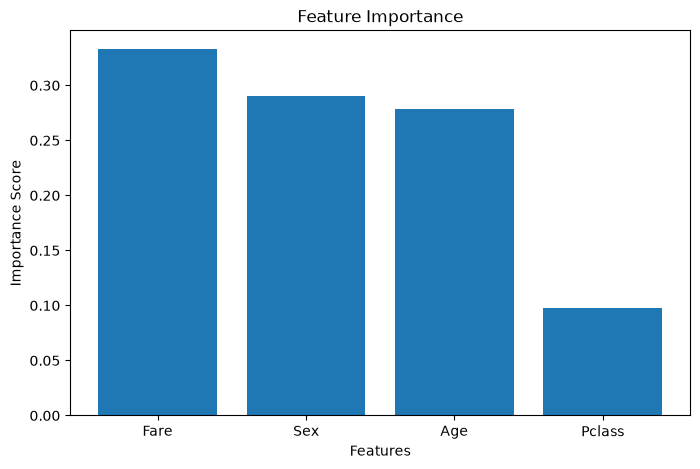

In [10]:
#4. Plot Top Feature Importances
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_

feature_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_imp = feature_imp.sort_values(
    by="Importance",
    ascending=False
)

print(feature_imp)

# Top 10 Features
top10 = feature_imp.head(10)

plt.figure(figsize=(8,5))
plt.bar(top10["Feature"],
        top10["Importance"])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

# PRACTICE

In [ ]:
#Project: Loan Approval Prediction
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
df = pd.read_csv("loan.csv")
X = df[['Income', 'LoanAmount', 'CreditScore']]
y = df['Approved']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

In [24]:
#Compare Accuracy
print("\nDecision Tree Report")
print(classification_report(y_test, dt_pred))

print("\nRandom Forest Report")
print(classification_report(y_test, rf_pred))


Decision Tree Report
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4


Random Forest Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [23]:
print("\nModel Comparison")
print("Decision Tree :", round(dt_accuracy*100,2), "%")
print("Random Forest :", round(rf_accuracy*100,2), "%")


Model Comparison
Decision Tree : 75.0 %
Random Forest : 100.0 %
